# 📊 Seaborn 기초 — 분포·범주·관계 분석 & 시각화 리포트 핵심 노트

**학습 범위**
- 18_01 분포와 범주 시각화
- 18_02 관계분석과 시각화리포트

> 나중에 복습할 때 바로 찾을 수 있도록  
> **목차 → 한눈에 보는 코드 → 개념 정의 → 왜 쓰는가 → 작동 원리 → 코드 → 실수 포인트 → 셀프 체크** 순서로 정리했습니다.

In [1]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

Duplicate key in file WindowsPath('c:/Users/mzlap/Desktop/KNA-Data-analysis-1st/.venv/Lib/site-packages/matplotlib/mpl-data/matplotlibrc'), line 851 ('font.family : Malgun Gothic')
Duplicate key in file WindowsPath('c:/Users/mzlap/Desktop/KNA-Data-analysis-1st/.venv/Lib/site-packages/matplotlib/mpl-data/matplotlibrc'), line 852 ('axes.unicode_minus : False')


✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


## 1. 📌 한 줄 요약 (Executive Summary)

Seaborn은 **Pandas DataFrame을 그대로 사용해 분포·범주·관계 그래프를 적은 코드로 빠르게 만드는 시각화 도구**입니다.

이번 단원의 핵심은 다음과 같습니다.

- 숫자 1개의 **분포** → `histplot()`
- 분포 요약 + **이상치** → `boxplot()`
- 범주별 **개수** → `countplot()`
- 범주별 숫자값의 **평균** → `barplot()`
- 숫자 2개의 **관계** → `scatterplot()`
- 여러 숫자 변수의 **상관관계** → `corr()` + `heatmap()`
- 여러 그래프를 묶은 **EDA/시각화 리포트** → `subplots()` + `savefig()`

## 2. 🗂️ 핵심 목차 및 개요

- **A. Seaborn 시작**
  - 왜 시각화하는가
  - Seaborn과 Matplotlib의 역할
  - `sns.set_theme()`
  - 한글 폰트 설정
  - DataFrame 구조 확인
- **B. 숫자형 데이터의 분포**
  - 분포란 무엇인가
  - `sns.histplot()`
  - `bins`
  - `kde`
  - `hue`
  - 분포 해석: 중심·퍼짐·치우침
- **C. 박스플롯과 이상치**
  - 중앙값·Q1·Q3·IQR
  - 상자·중앙값선·수염·이상치점
  - `sns.boxplot()`
  - 범주별 박스플롯
  - `hue`로 이중 비교
- **D. 범주형 데이터 비교**
  - `countplot()` — 개수
  - `barplot()` — 평균
  - `palette`와 `hue`
- **E. 두 변수 관계 분석**
  - `scatterplot()`
  - 양의 관계 / 음의 관계 / 관계 없음
  - 관계의 강도
  - `alpha`
  - `hue`로 위험 영역 찾기
- **F. 상관관계**
  - 상관계수
  - `df.corr(numeric_only=True)`
  - 상관행렬
  - `sns.heatmap()`
  - `annot`, `fmt`, `cmap`, `center`
- **G. 시각화 리포트**
  - EDA
  - 전체 → 분포 → 비교 → 관계
  - `plt.subplots()`
  - `ax=`
  - `tight_layout()`
  - `savefig()`
  - 사실 → 의미 → 행동

## 3. 💻 한눈에 보는 코드 정리

| 코드 | 무엇을 하는가 | 핵심 포인트 |
|---|---|---|
| `import seaborn as sns` | Seaborn 불러오기 | 별칭은 보통 `sns` |
| `sns.set_theme(style="whitegrid")` | 전체 그래프 테마 | 작업 시작 시 한 번 |
| `sns.histplot(data=df, x="온도")` | 숫자 1개 분포 | `x`는 숫자형 |
| `bins=20` | 히스토그램 구간 수 | 너무 작거나 크지 않게 |
| `kde=True` | 부드러운 분포 곡선 | 정확한 개수는 막대로 확인 |
| `hue="판정"` | 그룹별 색 구분 | 범주형 컬럼 사용 |
| `sns.boxplot(data=df, y="진동")` | 단일 센서 박스플롯 | 이상치 자동 표시 |
| `sns.boxplot(data=df, x="설비라인", y="진동")` | 범주별 분포 비교 | x=범주, y=숫자 |
| `sns.countplot(data=df, x="설비라인")` | 범주별 개수 | y 필요 없음 |
| `sns.barplot(data=df, x="설비라인", y="진동")` | 범주별 평균 | 기본 집계는 평균 |
| `sns.scatterplot(data=df, x="온도", y="진동")` | 두 변수 관계 | x,y 모두 숫자형 |
| `alpha=0.5` | 점 투명도 | 겹침/밀도 확인 |
| `df.corr(numeric_only=True)` | 상관행렬 계산 | 글자형 자동 제외 |
| `sns.heatmap(corr)` | 상관행렬 시각화 | 원본 df가 아니라 `corr` |
| `annot=True` | heatmap 숫자 표시 | 각 칸에 상관계수 |
| `fmt=".2f"` | 소수점 2자리 | `annot=True`와 자주 함께 |
| `cmap="coolwarm"` | 양/음 색상 구분 | 빨강=양, 파랑=음 |
| `center=0` | 0을 색 중앙값으로 | 상관 heatmap에서 중요 |
| `plt.subplots(1, 2, ...)` | 여러 그래프 한 화면 | `ax=`로 위치 지정 |
| `plt.tight_layout()` | 그래프 겹침 정리 | 마지막에 자주 사용 |
| `plt.savefig(..., dpi=150)` | 그래프 저장 | `show()`보다 먼저 |

# 4. 💡 Seaborn 시작

## 4-1. 왜 데이터를 그림으로 보는가?

### 개념 정의
시각화는 데이터를 예쁘게 꾸미는 일이 아니라 **숫자표에서 놓치기 쉬운 패턴·이상신호를 빠르게 찾는 분석 도구**입니다.

### 왜 사용하는가?
사람은 수백 개 숫자를 동시에 비교하는 데 약하지만, **모양·색·방향 차이**는 매우 빠르게 알아차립니다.

예를 들어 평균만 보면 정상처럼 보여도 그래프에서는 일부 구간이 갑자기 튀는 현상이 바로 드러날 수 있습니다.

### 핵심 원리
**정상 상태의 모양을 알아야 이상 상태를 구분할 수 있습니다.**

## 4-2. Seaborn을 쓰는 이유

### 개념 정의
Seaborn은 Matplotlib 위에서 동작하는 **통계 시각화 라이브러리**입니다.

### 장점 3가지
1. **적은 코드**로 그래프 작성
2. **Pandas DataFrame과 궁합이 좋음**
3. 분포·박스플롯·heatmap 등 **통계 그래프를 기본 제공**

### Seaborn과 Matplotlib의 역할
```text
sns → 그래프 본체
plt → 제목·축·크기·저장·출력
```

즉, Seaborn을 써도 Matplotlib을 함께 사용합니다.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 전체 그래프 테마 지정
# 작업 시작 시 한 번 설정하면 됨
sns.set_theme(style="whitegrid")

### 꼭 짚고 넘어갈 포인트
- `pd` = pandas
- `plt` = matplotlib.pyplot
- `sns` = seaborn

이 별칭들은 사실상 공통 관례이므로 임의로 바꾸지 않는 것이 좋습니다.

## 4-3. 한글 폰트 설정

한글이 네모(□)로 표시되는 것은 코드 오류가 아니라 **현재 글꼴에 한글 자형이 없기 때문**입니다.

강의자료 기준:
- Windows → `Malgun Gothic`
- Mac → `AppleGothic`

또는 `koreanize_matplotlib`을 사용할 수 있습니다.

In [3]:
# Windows
# plt.rcParams['font.family'] = 'Malgun Gothic'

# Mac
# plt.rcParams['font.family'] = 'AppleGothic'

# 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 다른 방법
# import koreanize_matplotlib

## 4-4. 데이터 불러오기와 구조 확인

시각화 전에 먼저 **데이터의 행·열 개수와 컬럼 종류를 확인**해야 합니다.

In [4]:
# 강의자료의 실습 흐름 예시
df = pd.read_csv(
    "equipment_sensor.csv",
    encoding="utf-8-sig"
)

# 행·열 개수
print(df.shape)

# 앞부분 확인
display(df.head())

# 컬럼 이름 확인
print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'equipment_sensor.csv'

### 강의자료의 데이터 구조
- 숫자형: 온도 · 압력 · 진동 · 전류 · 습도
- 범주형: 설비라인 · 판정
- 결측치 포함: 압력, 습도

**어떤 그래프를 쓸지는 데이터 타입과 질문에 따라 결정됩니다.**

# 5. 📦 분포와 `histplot()`

## 5-1. 분포란 무엇인가?

### 개념 정의
값들이 **어느 구간에 얼마나 모여 있는지** 나타내는 것입니다.

### 왜 중요한가?
평소 진동이 2 근처에 몰려 있다는 사실을 알고 있어야 4~5 같은 값이 나왔을 때 **드문 값 또는 이상 신호 후보**라고 판단할 수 있습니다.

### 핵심
분포는 **정상과 이상을 나누는 기준**을 만들어 줍니다.

## 5-2. 히스토그램의 원리

히스토그램은 다음 3단계로 만들어집니다.

```text
1. 값의 범위를 여러 구간으로 나눈다
2. 각 구간에 데이터가 몇 개 들어가는지 센다
3. 개수만큼 막대 높이를 만든다
```

그래서 히스토그램의 막대 높이는 **구간별 데이터 개수**를 의미합니다.

## 5-3. 히스토그램 vs 막대그래프

| 구분 | 히스토그램 | 막대그래프 |
|---|---|---|
| 보는 것 | 숫자 1개의 분포 | 서로 다른 범주의 크기 |
| 가로축 | 연속된 숫자 구간 | 독립적인 범주 |
| 막대 간격 | 붙어 있음 | 떨어져 있음 |
| 예 | 온도 분포 | A/B/C 라인 개수 |

겉모습은 비슷하지만 **질문 자체가 다릅니다.**

## 5-4. `sns.histplot()` 기본 사용법

### 개념 정의
DataFrame과 숫자형 컬럼을 지정하면 해당 센서의 분포를 히스토그램으로 그립니다.

### 기본 패턴
```text
sns 함수로 본체
→ plt 제목/축
→ plt.show()
```

In [ ]:
sns.histplot(
    data=df,
    x="온도"         # 분포를 볼 숫자형 컬럼
)

plt.title("온도 분포")
plt.xlabel("온도(℃)")
plt.ylabel("개수")
plt.show()

### ⚠️ 자주 하는 실수
- `x=온도` ❌ → `x="온도"` ✅
- 실제 DataFrame에 없는 컬럼 이름 사용
- 범주형 컬럼을 `x`에 넣고 숫자 분포처럼 해석

컬럼명이 헷갈리면 먼저:
```python
df.columns
```
로 확인하세요.

## 5-5. `bins` — 구간 수 조절

### 개념 정의
히스토그램을 몇 개 구간으로 나눌지 결정합니다.

- 너무 작음 → 분포가 뭉뚱그려짐
- 적절함 → 봉우리와 꼬리가 잘 보임
- 너무 큼 → 막대가 듬성듬성하고 빈 구간 증가

강의자료에서는 **300개 데이터의 경우 15~30 정도가 무난**하다고 설명합니다.

정답인 bins는 없습니다.  
**분포가 가장 잘 보이는 값을 직접 바꿔보는 것**이 중요합니다.

In [ ]:
# bins를 바꾸어 분포를 비교하는 예시
sns.histplot(
    data=df,
    x="온도",
    bins=20
)

plt.title("온도 분포 - bins=20")
plt.show()

## 5-6. `kde=True` — 부드러운 분포 곡선

### 개념 정의
히스토그램 막대 위에 분포의 전체 흐름을 부드러운 곡선으로 표시합니다.

### 왜 사용하는가?
봉우리의 위치와 전체적인 분포 모양을 빠르게 파악하기 좋습니다.

### 주의
KDE 곡선은 **추정된 곡선**입니다.  
정확한 개수는 히스토그램 막대로 확인해야 합니다.

In [ ]:
sns.histplot(
    data=df,
    x="온도",
    bins=20,
    kde=True        # 부드러운 분포 곡선 추가
)

plt.title("온도 분포 (KDE 포함)")
plt.xlabel("온도(℃)")
plt.show()

### KDE에서 읽을 수 있는 것
- 봉우리 1개 → 하나의 중심 집단일 가능성
- 봉우리 2개 이상 → 서로 다른 집단이 섞였을 가능성
- 꼬리가 길게 뻗음 → 드문 극단값 가능성

## 5-7. `hue` — 그룹별 분포 겹쳐 보기

### 개념 정의
범주형 컬럼을 `hue`에 넣으면 그룹별 색과 범례가 자동 적용됩니다.

### 적합한 컬럼
- 판정: 양품 / 불량
- 설비라인: A / B / C

### 부적합한 컬럼
온도처럼 연속 숫자형 값은 hue로 넣으면 색 종류가 지나치게 많아져 해석이 어렵습니다.

In [ ]:
sns.histplot(
    data=df,
    x="진동",
    hue="판정",      # 양품/불량 색 구분
    kde=True
)

plt.title("판정별 진동 분포")
plt.xlabel("진동(mm/s)")
plt.show()

### 그래프에서 읽을 포인트
예를 들어 **불량 분포가 양품보다 오른쪽에 치우친다면**  
“불량에서 해당 센서값이 더 높은 경향”이 있다는 단서가 됩니다.

단, 그래프만 보고 원인이라고 단정하면 안 됩니다.

## 5-8. 분포 해석 체크리스트 3가지

분포 그래프를 보면 항상 아래 세 가지를 확인하세요.

| 체크 | 질문 | 해석 |
|---|---|---|
| 중심 | 어디에 가장 많이 모였나? | 대표적인 작동 수준 |
| 퍼짐 | 좁게 모였나, 넓게 퍼졌나? | 안정성/변동성 |
| 치우침 | 한쪽 꼬리가 긴가? | 드문 극단값 신호 |

특히 **오른쪽 꼬리가 길면 큰 값 쪽 이상신호 가능성**을 의심할 수 있습니다.

# 6. 📦 박스플롯 — 분포 요약 + 이상치

## 6-1. 박스플롯이 필요한 이유

히스토그램은 분포 모양을 잘 보여주지만  
“정상 범위가 어디까지인지”, “이상치가 몇 개인지”를 바로 읽기에는 애매할 수 있습니다.

박스플롯은 다음을 한 번에 보여줍니다.

- 중앙값
- Q1
- Q3
- IQR
- 정상 범위
- 이상치 점

즉, **분포 요약과 이상치 표시를 동시에 수행하는 그래프**입니다.

## 6-2. 중앙값과 사분위수

### 중앙값
값을 크기순으로 정렬했을 때 **정확히 가운데 위치한 값**입니다.

예:
```text
2.0, 2.1, 2.2, 2.3, 8.0
평균 = 3.32
중앙값 = 2.2
```

극단값 8.0 때문에 평균은 크게 올라가지만 중앙값은 덜 흔들립니다.  
그래서 이상치가 섞이기 쉬운 센서 데이터에서는 중앙값이 유용합니다.

### 사분위수
- Q1 = 25% 지점
- Q3 = 75% 지점
- IQR = Q3 - Q1

가운데 50%의 데이터가 Q1~Q3 사이에 들어갑니다.

## 6-3. 박스플롯의 네 부분

| 부분 | 의미 |
|---|---|
| 상자 | Q1 ~ Q3, 가운데 50% |
| 중앙값선 | 데이터의 가운데 값 |
| 수염 | 정상 범위의 끝 |
| 이상치 점 | 정상 범위를 벗어난 값 |

상자가 길수록 데이터가 더 넓게 퍼져 있고,  
짧을수록 값이 좁은 범위에 모여 있다고 볼 수 있습니다.

## 6-4. `sns.boxplot()` 기본 사용법

단일 센서의 분포를 볼 때는 숫자형 컬럼을 `y`에 넣습니다.

In [ ]:
sns.boxplot(
    data=df,
    y="진동"
)

plt.title("진동 박스플롯")
plt.ylabel("진동(mm/s)")
plt.show()

### 핵심 포인트
Q1, Q3, 중앙값, 수염, 이상치점을 **Seaborn이 자동 계산**합니다.

사분위수를 직접 계산하지 않아도 됩니다.

또한 결측치는 자동으로 제외하고 남은 값만 사용해 그래프를 그립니다.

## 6-5. 범주별 박스플롯

### 목적
라인별로 센서값의 **중앙값·퍼짐·이상치 차이**를 한눈에 비교합니다.

### 구조
- `x` = 범주형
- `y` = 숫자형

In [ ]:
sns.boxplot(
    data=df,
    x="설비라인",
    y="진동"
)

plt.title("라인별 진동 분포")
plt.xlabel("설비라인")
plt.ylabel("진동(mm/s)")
plt.show()

### 해석 포인트
- 중앙값이 가장 높은 라인은?
- 상자가 가장 긴 라인은?
- 특정 라인에 이상치가 유독 많은가?

이런 차이를 보면 **점검 우선순위**를 정하는 데 도움이 됩니다.

## 6-6. `hue`로 두 기준 동시에 비교

`x="설비라인"`에 더해 `hue="판정"`을 주면  
**라인별 × 양품/불량**을 동시에 비교할 수 있습니다.

In [ ]:
sns.boxplot(
    data=df,
    x="설비라인",
    y="진동",
    hue="판정"
)

plt.title("라인별 · 판정별 진동")
plt.show()

### 중요 해석 원칙
한두 그룹에서만 보이는 패턴은 우연일 수 있지만,  
**모든 라인에서 반복되는 양품/불량 차이**는 더 신뢰할 수 있는 신호입니다.

단, `hue`를 지나치게 많이 사용하면 그래프가 복잡해집니다.

# 7. 📊 범주형 데이터 — `countplot()`과 `barplot()`

## 7-1. 범주형 데이터는 어떻게 보는가?

숫자형 데이터는 **분포**를 보고,  
범주형 데이터는 보통 아래 두 가지를 봅니다.

1. 각 범주가 **몇 개인가** → `countplot()`
2. 각 범주의 숫자값 **평균이 얼마인가** → `barplot()`

## 7-2. `countplot()` — 범주별 개수

### 질문
“각 범주가 몇 개인가?”

### 특징
- `x`만 지정
- y값을 따로 줄 필요 없음
- Seaborn이 자동으로 개수를 집계

In [ ]:
sns.countplot(
    data=df,
    x="설비라인"
)

plt.title("라인별 데이터 개수")
plt.xlabel("설비라인")
plt.ylabel("개수")
plt.show()

### 실무 활용
데이터 불균형 확인에 유용합니다.

강의자료 예시에서는:
- A라인 130
- B라인 99
- C라인 71

처럼 범주별 표본 수 차이를 바로 확인합니다.

## 7-3. `barplot()` — 범주별 평균

### 질문
“각 범주의 평균값이 얼마인가?”

### 특징
- `x` = 범주
- `y` = 숫자
- 막대 높이는 기본적으로 **평균값**

In [ ]:
sns.barplot(
    data=df,
    x="설비라인",
    y="진동"
)

plt.title("라인별 평균 진동")
plt.xlabel("설비라인")
plt.ylabel("평균 진동(mm/s)")
plt.show()

### barplot의 오차선
막대 위 가는 세로선은 평균값의 **오차 범위 / 불확실성**을 나타냅니다.

- 길다 → 평균의 불확실성이 더 큼
- 짧다 → 평균이 상대적으로 안정적

## 7-4. countplot vs barplot

| 구분 | countplot | barplot |
|---|---|---|
| 질문 | 몇 개인가? | 평균이 얼마인가? |
| 필요한 값 | x | x + y |
| 막대 높이 | 개수 | 평균 |
| y 필요 여부 | 없음 | 있음 |

### 가장 쉬운 구분
**y값이 필요하면 barplot, x만 있으면 countplot**

### ⚠️ 자주 하는 실수

`라인별 진동을 보고 싶다`는 생각만 하고 `countplot()`을 쓰면  
진동값은 무시되고 **라인별 행 개수만 계산**됩니다.

그래프를 고르기 전에 질문을 명확히 하세요.

- 라인별 데이터 **개수**? → countplot
- 라인별 진동 **평균**? → barplot

## 7-5. `palette`와 `hue`

강의자료에서는 최신 Seaborn 사용 방식으로  
**palette를 사용할 때 색을 나누는 기준을 hue로 명확히 지정**하는 방식을 설명합니다.

### 색만 바꾸고 싶을 때
- `hue` = x와 같은 컬럼
- `legend=False`

In [ ]:
sns.countplot(
    data=df,
    x="설비라인",
    hue="설비라인",     # x와 같은 기준
    palette="Set2",
    legend=False        # x축에 이미 범주명이 있으므로 범례 끔
)

plt.show()

### 색으로 다른 기준을 표현할 때
- x = 설비라인
- hue = 판정
- 범례 유지

이 경우 색 자체에 새로운 정보가 있으므로 범례가 필요합니다.

In [ ]:
sns.countplot(
    data=df,
    x="설비라인",
    hue="판정"
)

plt.title("라인별 양품·불량 개수")
plt.show()

# 8. 🔵 산점도 — 두 변수 관계 분석

## 8-1. 두 변수의 관계란?

### 개념 정의
한 값이 변할 때 다른 값이 **함께 어떻게 움직이는지** 보는 것입니다.

예:
- 온도가 올라갈 때 진동도 같이 올라가는가?
- 온도가 올라갈 때 압력은 내려가는가?

### 왜 중요한가?
평소 같이 움직이던 두 센서의 관계가 갑자기 깨지는 순간이  
**이상신호**가 될 수 있습니다.

## 8-2. 산점도의 원리

측정값 하나가 점 하나가 됩니다.

예:
```text
온도 = 80
진동 = 3.0

→ (80, 3.0) 위치에 점 하나
```

300행 데이터라면 최대 300개의 점이 찍힙니다.

중요한 것은 **점 하나가 아니라 전체 점들이 이루는 방향과 모양**입니다.

## 8-3. 산점도의 세 패턴

| 모양 | 관계 | 의미 |
|---|---|---|
| ↗ 우상향 | 양의 관계 | 한 값이 커질수록 다른 값도 커짐 |
| ● 둥글게 흩어짐 | 관계 없음 | 뚜렷한 방향 없음 |
| ↘ 우하향 | 음의 관계 | 한 값이 커질수록 다른 값은 작아짐 |

## 8-4. `sns.scatterplot()` 기본 사용법

두 숫자형 컬럼을 `x`, `y`에 각각 지정합니다.

In [ ]:
sns.scatterplot(
    data=df,
    x="온도",
    y="진동"
)

plt.title("온도와 진동의 관계")
plt.xlabel("온도(℃)")
plt.ylabel("진동(mm/s)")
plt.show()

### 축 배치 관행
보통:
- 원인 후보 → x
- 결과 후보 → y

하지만 x와 y를 바꿔도 **상관의 존재 자체는 바뀌지 않습니다.**  
다만 읽는 관점이 달라집니다.

## 8-5. `alpha` — 점이 겹칠 때

점이 많아 겹치면 밀도가 보이지 않을 수 있습니다.

`alpha=0.5`처럼 반투명하게 하면:
- 많이 겹친 곳 → 진하게
- 드문 곳 → 연하게

보여서 데이터 밀도까지 확인할 수 있습니다.

In [ ]:
sns.scatterplot(
    data=df,
    x="온도",
    y="진동",
    alpha=0.5
)

plt.title("온도-진동 관계")
plt.show()

## 8-6. `hue`로 위험 영역 찾기

범주형 판정값을 색으로 표시하면  
어느 영역에 불량이 몰리는지 확인할 수 있습니다.

In [ ]:
sns.scatterplot(
    data=df,
    x="온도",
    y="진동",
    hue="판정",
    alpha=0.7
)

plt.title("판정별 온도-진동 관계")
plt.show()

### 해석 예
불량 점들이 오른쪽 위에 몰린다면:

> 온도와 진동이 함께 높은 영역에 불량이 상대적으로 많이 나타나는 경향

이라고 표현할 수 있습니다.

❌ “고온과 고진동이 불량의 원인이다”라고 단정하면 안 됩니다.

## 8-7. 관계의 방향 + 강도

산점도는 방향뿐 아니라 **점들이 얼마나 빽빽하게 모여 있는지**도 봅니다.

- 점들이 한 줄 가까이 모임 → 상대적으로 강한 관계
- 점들이 넓게 퍼짐 → 상대적으로 약한 관계

# 9. 🔗 상관관계와 상관계수

## 9-1. 상관계수란?

두 변수의 관계를 **-1 ~ +1 사이 숫자 하나**로 표현한 값입니다.

### 부호 = 방향
- `+` → 양의 관계
- `-` → 음의 관계

### 절댓값 크기 = 강도
- 1에 가까울수록 강함
- 0에 가까울수록 약함

## 9-2. 강의자료의 해석 기준

| 절댓값 | 해석 |
|---:|---|
| 0.7 이상 | 강함 |
| 0.4 ~ 0.7 | 중간 |
| 0.2 ~ 0.4 | 약함 |

강의자료 예시:
- 온도-전류 ≈ `+0.51`
- 온도-진동 ≈ `+0.31`
- 온도-압력 ≈ `-0.24`

### ⚠️ 주의
상관계수가 높다고 해서 **원인-결과 관계를 증명하는 것은 아닙니다.**

## 9-3. `df.corr()` — 상관행렬 만들기

숫자형 컬럼끼리 모든 쌍의 상관계수를 한 번에 계산합니다.

In [ ]:
corr = df.corr(
    numeric_only=True   # 숫자형 컬럼만 사용
)

# 소수점 둘째 자리까지 보기
print(corr.round(2))

## 9-4. 상관행렬의 규칙

### 규칙 1. 대각선은 항상 1
자기 자신과의 상관은 완벽하므로 `1.00`

### 규칙 2. 위아래는 대칭
```text
온도-전류 = 전류-온도
```

따라서 대각선 기준으로 절반만 봐도 모든 관계를 알 수 있습니다.

# 10. 🌡️ Heatmap — 상관행렬을 색으로 보기

## 10-1. 왜 heatmap을 사용하는가?

상관행렬은 숫자가 많아지면 비교하기 어렵습니다.

heatmap은 각 상관계수를 색으로 바꾸어:
- 강한 양의 관계
- 약한 관계
- 강한 음의 관계

를 한눈에 찾게 해 줍니다.

## 10-2. `sns.heatmap()` 기본 사용법

### 매우 중요한 포인트
`heatmap()`에는 **원본 df가 아니라 상관행렬 corr**을 넣습니다.

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr
)

plt.show()

### ⚠️ 입문자가 가장 많이 헷갈리는 부분
```python
sns.heatmap(df)      # ❌ 상관분석 목적이라면 잘못
sns.heatmap(corr)    # ✅ corr 결과를 넣기
```

## 10-3. `annot=True`, `fmt=".2f"`

- `annot=True` → 각 칸에 실제 상관계수 표시
- `fmt=".2f"` → 소수점 둘째 자리까지 정리

색으로 전체 패턴을 보고, 숫자로 정확한 값을 확인합니다.

In [ ]:
sns.heatmap(
    corr,
    annot=True,      # 숫자 표시
    fmt=".2f"        # 소수점 두 자리
)

plt.title("센서 상관관계")
plt.show()

## 10-4. `cmap="coolwarm"`, `center=0`

상관관계는 양수/음수 방향이 중요하므로  
색의 중앙을 0으로 맞추면 해석하기 쉽습니다.

- 빨강 계열 → 양의 관계
- 파랑 계열 → 음의 관계
- 중앙의 연한 색 → 0에 가까운 약한 관계

In [ ]:
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("센서 상관관계")
plt.show()

## 10-5. 상관 heatmap 완성형

```python
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
```

이 네 옵션을 **한 세트처럼 기억**하면 좋습니다.

- `annot` → 숫자
- `fmt` → 자리수
- `cmap` → 색상 체계
- `center` → 0을 기준으로 색 분리

# 11. 🧭 그래프 선택 치트시트

그래프는 “예쁘게 보이는 것”이 아니라  
**내가 무엇을 알고 싶은가 + 데이터가 어떤 타입인가**로 고릅니다.

| 알고 싶은 것 | 데이터 | 그래프 |
|---|---|---|
| 분포 모양 | 숫자 1개 | `histplot` |
| 요약 + 이상치 | 숫자 1개 | `boxplot` |
| 범주별 개수 | 범주 | `countplot` |
| 범주별 평균 | 범주 + 숫자 | `barplot` |
| 두 변수 관계 | 숫자 2개 | `scatterplot` |
| 여러 변수 관계 | 숫자 여러 개 | `corr` + `heatmap` |

### 선택 기준 2가지
1. 무엇을 보려는가? → **분포 / 비교 / 관계**
2. 데이터는 무엇인가? → **숫자형 / 범주형**

# 12. 🧪 EDA와 시각화 리포트

## 12-1. EDA란?

**Exploratory Data Analysis**, 탐색적 데이터 분석입니다.

그래프를 사용해:
- 분포
- 이상치
- 범주 차이
- 변수 관계

를 탐색하며 숨은 패턴을 찾는 과정입니다.

### 핵심
그래프는 목적이 아니라 **발견을 위한 수단**입니다.

## 12-2. 좋은 시각화 리포트란?

그래프가 많은 리포트가 좋은 리포트가 아닙니다.

좋은 리포트는:

> **핵심 발견이 명확하고, 보는 사람이 바로 이해할 수 있는 리포트**

입니다.

EDA에서 만든 모든 그래프를 넣기보다  
**메시지가 있는 그래프만 선택**하는 것이 중요합니다.

## 12-3. 리포트 구성 순서

강의자료의 권장 흐름:

```text
1. 전체 파악
   ↓
2. 한 변수 분포
   ↓
3. 범주별 비교
   ↓
4. 변수 관계
```

### 예
1. 전체 데이터 개수 → `countplot`
2. 정상 범위/이상치 → `histplot`, `boxplot`
3. 라인/판정 차이 → `boxplot(hue)`, `barplot`
4. 센서 관계 → `scatterplot`, `heatmap`

**큰 그림 → 세부 → 관계** 순서로 읽는 사람이 길을 잃지 않게 합니다.

# 13. 🖼️ 여러 그래프 한 화면에 — `subplots()`

## 13-1. 기본 사용법

`plt.subplots()`로 여러 칸을 만들고  
Seaborn 함수의 `ax=` 옵션으로 어느 칸에 그릴지 지정합니다.

In [ ]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

# 첫 번째 칸
sns.histplot(
    data=df,
    x="온도",
    ax=ax1
)
ax1.set_title("온도 분포")

# 두 번째 칸
sns.boxplot(
    data=df,
    x="설비라인",
    y="진동",
    ax=ax2
)
ax2.set_title("라인별 진동")

# 그래프끼리 겹치지 않게 간격 조정
plt.tight_layout()

plt.show()

### 꼭 기억할 문법
```python
fig, (ax1, ax2) = plt.subplots(1, 2)
```

- `1` = 행 수
- `2` = 열 수
- `ax1`, `ax2` = 각 칸
- Seaborn 함수에 `ax=ax1`, `ax=ax2` 전달

## 13-2. 칸별 제목과 전체 제목

- 칸별 제목 → `ax1.set_title()`
- 전체 제목 → `fig.suptitle()` 또는 `plt.suptitle()`
- 간격 조정 → `plt.tight_layout()`

여러 그래프를 한 화면에 넣을 때는  
각 칸이 무엇을 의미하는지 제목을 반드시 붙이는 것이 좋습니다.

# 14. 💾 그래프와 리포트 저장

## 14-1. `savefig()`는 `show()`보다 먼저

강의자료에서 반복해서 강조하는 순서입니다.

```text
그래프 그리기
→ savefig 저장
→ show 확인
```

`show()`를 먼저 호출한 뒤 저장하면 환경에 따라 빈 이미지가 저장될 수 있으므로  
**저장을 먼저 하는 습관**을 들이는 것이 안전합니다.

In [ ]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

# 먼저 저장
plt.savefig(
    "리포트.png",
    dpi=150,
    bbox_inches="tight"
)

# 그 다음 화면 확인
plt.show()

## 14-2. 저장 옵션

### `dpi`
이미지의 선명도

- 150 → 일반 리포트용
- 300 → 더 선명한 출력용

### `bbox_inches="tight"`
그래프 주변의 불필요한 여백을 줄입니다.

### 파일 형식
- `.png` → 일반 리포트 공유
- `.jpg` → 용량 절약
- `.pdf` → 인쇄용

# 15. ✍️ 그래프 해석을 문장으로 쓰는 법

그래프만 붙여놓으면 리포트가 완성되지 않습니다.

강의자료에서는 다음 3단계로 정리합니다.

```text
사실 → 의미 → 행동
```

### 예시

**사실**  
“진동 박스플롯에서 정상 범위를 벗어난 점이 6개 보인다.”

**의미**  
“일부 측정값에서 평소 범위보다 큰 진동이 발생했다.”

**행동**  
“해당 측정 구간 또는 설비를 우선 점검 대상으로 확인한다.”

## 15-1. 단정하지 않기

그래프가 실제 보여준 것만 표현해야 합니다.

| ❌ 단정 표현 | ✅ 사실 중심 표현 |
|---|---|
| 온도가 전류의 원인이다 | 온도와 전류가 함께 높아지는 경향 |
| 이 설비는 고장이다 | 이 설비의 진동이 정상 범위 밖에 위치 |
| 고온은 반드시 불량을 만든다 | 고온 영역에 불량이 상대적으로 많이 분포 |

특히 **상관관계는 인과관계가 아닙니다.**

## 15-2. 보는 사람에 따라 그래프 선택

### 설비 담당자
- 이상치
- 위험 구간
- 실제 점검 대상

→ `boxplot`, `scatterplot`

### 경영진
- 라인별 차이
- 전체 불량 비교
- 큰 그림

→ `countplot`, `barplot`

같은 데이터라도 **누가 보는가**에 따라 중요한 그래프가 달라집니다.

# 16. 🧩 2×2 시각화 리포트 예시

아래 코드는 이번 두 강의의 핵심 그래프를 한 번에 복습하는 예시입니다.

- 분포
- 박스플롯
- 산점도
- heatmap

In [ ]:
# 숫자 컬럼 상관행렬
corr = df.corr(numeric_only=True)

# 2행 2열 리포트 도화지
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9)
)

# ① 온도 분포
sns.histplot(
    data=df,
    x="온도",
    bins=20,
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("온도 분포")

# ② 진동 박스플롯
sns.boxplot(
    data=df,
    y="진동",
    ax=axes[0, 1]
)
axes[0, 1].set_title("진동 이상치 확인")

# ③ 온도-진동 산점도
sns.scatterplot(
    data=df,
    x="온도",
    y="진동",
    hue="판정",
    alpha=0.7,
    ax=axes[1, 0]
)
axes[1, 0].set_title("판정별 온도-진동 관계")

# ④ 상관 heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1, 1]
)
axes[1, 1].set_title("센서 상관관계")

# 전체 제목
fig.suptitle(
    "설비 센서 EDA 시각화 리포트",
    fontsize=16
)

# 간격 정리
plt.tight_layout()

# 저장은 show보다 먼저
plt.savefig(
    "seaborn_eda_report.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# 17. ⚡ 시험/실무 핵심 포인트 & 오해하기 쉬운 점

### ① `histplot`과 `countplot`을 헷갈리지 않기
- `histplot` → 숫자 하나의 **분포**
- `countplot` → 범주별 **개수**

---

### ② `countplot`과 `barplot` 구분
- “몇 개인가?” → `countplot`
- “평균이 얼마인가?” → `barplot`

---

### ③ `hue`에는 범주형 컬럼
`판정`, `설비라인`처럼 몇 개 그룹으로 나뉘는 값이 적합합니다.

---

### ④ heatmap에는 원본 df가 아니라 상관행렬
```python
corr = df.corr(numeric_only=True)
sns.heatmap(corr)
```

---

### ⑤ 상관관계 ≠ 인과관계
상관계수나 산점도가 보여주는 것은 “함께 움직이는 경향”이지 원인을 증명하는 것이 아닙니다.

---

### ⑥ 박스플롯의 이상치 점 = 무조건 고장 아님
정상 범위 밖 값이라는 뜻이지, 즉시 고장으로 단정할 수는 없습니다.

---

### ⑦ `savefig()`는 `show()`보다 먼저
```python
plt.savefig(...)
plt.show()
```

# 18. 🧠 최종 암기 카드

```text
숫자 1개 분포        → histplot
분포 요약 + 이상치   → boxplot
범주 개수            → countplot
범주 평균            → barplot
숫자 2개 관계        → scatterplot
여러 숫자 관계       → corr + heatmap

그룹 색 구분          → hue
히스토그램 구간       → bins
분포 곡선            → kde
점 투명도            → alpha

heatmap 숫자          → annot
소수점 자리           → fmt
양/음 색상            → cmap
0 기준 색 중앙        → center

여러 그래프           → subplots
그래프 자리           → ax=
간격 정리             → tight_layout
저장                  → savefig
화면 출력             → show
```

# 19. 🔍 1분 셀프 체크 퀴즈

### Q1.
설비라인 A/B/C가 각각 몇 행씩 존재하는지 알고 싶습니다.  
어떤 그래프를 사용해야 할까요?

**정답:** `sns.countplot()`  
**해설:** 범주별 **개수**를 자동 집계해 막대로 보여줍니다.

---

### Q2.
라인별 평균 진동을 비교하려고 합니다.  
`countplot()`과 `barplot()` 중 무엇을 사용해야 할까요?

**정답:** `sns.barplot()`  
**해설:** x에는 라인, y에는 진동을 넣어 **범주별 평균값**을 비교합니다.

---

### Q3.
여러 센서의 상관관계를 heatmap으로 그리고 싶습니다.  
`heatmap()`에 직접 넣어야 하는 값은 `df`일까요, `corr`일까요?

**정답:** `corr`  
**해설:** 먼저 `df.corr(numeric_only=True)`로 상관행렬을 만든 뒤 그 결과를 heatmap에 넣습니다.

# 20. 🎯 초급 실습 과제

아래 조건대로 하나의 2×2 시각화 리포트를 만들어 보세요.

### 조건

#### 1번 칸
- `전류` 히스토그램
- `bins=20`
- `kde=True`

#### 2번 칸
- `설비라인`별 `진동` 박스플롯

#### 3번 칸
- x = `온도`
- y = `전류`
- hue = `판정`
- `alpha=0.6`

#### 4번 칸
- 숫자형 컬럼 상관행렬
- `annot=True`
- `fmt=".2f"`
- `cmap="coolwarm"`
- `center=0`

### 추가 조건
- 전체 크기 `(12, 9)`
- 각 칸에 제목 추가
- `tight_layout()` 적용
- `seaborn_practice_report.png`로 저장
- `savefig()` 다음에 `show()` 실행

> 정답 코드는 직접 작성해 본 뒤 확인하는 것이 가장 좋습니다.

---
## 📚 출처

이 노트는 제공된 강의자료의 내용과 표현 흐름을 기준으로 정리했습니다.

1. **18_01_분포와_범주_시각화_58_260824_3.pdf**
   - Seaborn 시작
   - histplot
   - bins / kde / hue
   - boxplot
   - countplot
   - barplot
   - palette

2. **18_02_관계분석과_시각화리포트_58_260824_4.pdf**
   - scatterplot
   - 상관계수
   - corr
   - heatmap
   - subplots
   - EDA
   - 시각화 리포트
   - savefig

<!-- supplemental_reading_guide_v1 -->
# 21. 👁️ Seaborn 그래프·결과 읽는 법 & 상황별 선택

아래 데모는 **그래프 해석 연습용 합성 데이터**입니다. 강의자료의 실제 CSV 계산 결과가 아닙니다.

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(12)
n = 180
line = np.random.choice(["A라인","B라인","C라인"], n, p=[0.4,0.35,0.25])
effect = pd.Series(line).map({"A라인":0.0,"B라인":2.0,"C라인":4.0}).to_numpy()

temperature = 70 + effect + np.random.normal(0,3.2,n)
vibration = 0.055*temperature - 1.6 + np.random.normal(0,0.28,n)
vibration[[12,75,133]] += [1.7,1.3,1.8]

judgement = np.where((temperature>76)&(vibration>2.8),"불량","양품")

demo_df = pd.DataFrame({
    "설비라인": line,
    "온도": temperature,
    "진동": vibration,
    "판정": judgement
})

print("데이터 크기:", demo_df.shape)
display(demo_df.head())
print(demo_df["판정"].value_counts())

데이터 크기: (180, 4)


,설비라인,온도,진동,판정
0,A라인,70.568800,2.269005,양품
1,B라인,72.102419,2.179053,양품
2,A라인,76.186290,2.944529,불량
3,B라인,68.601297,2.271247,양품
4,A라인,67.655587,2.327605,양품


판정
양품    172
불량      8
Name: count, dtype: int64


## 21-1. `histplot()` — 중심·퍼짐·꼬리

Seaborn에서:
```python
sns.histplot(data=demo_df, x="온도", bins=15, kde=True)
```

/tmp/ipykernel_957/2002022685.py:6: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2002022685.py:6: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2002022685.py:6: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2002022685.py:6: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2002022685.py:6: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2002022685.py:6: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2002022685.py:6: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyke

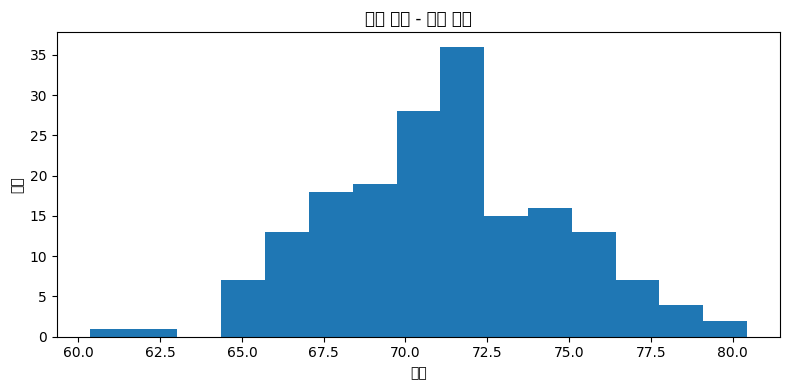

평균: 71.24
중앙값: 71.34
표준편차: 3.45


In [ ]:
plt.figure(figsize=(8,4))
plt.hist(demo_df["온도"], bins=15)
plt.title("온도 분포 - 해석 연습")
plt.xlabel("온도")
plt.ylabel("개수")
plt.tight_layout()
plt.show()

print("평균:", round(demo_df["온도"].mean(),2))
print("중앙값:", round(demo_df["온도"].median(),2))
print("표준편차:", round(demo_df["온도"].std(),2))

### 🔍 분포에서 볼 것
- 가장 많이 몰린 구간
- 퍼짐의 크기
- 한쪽 꼬리
- 극단값 후보

`kde=True`는 전체 모양을 부드럽게 보는 데 유용하지만 정확한 개수는 막대가 더 직접적입니다.

## 21-2. `boxplot()` — 중앙값·IQR·이상치 후보

Seaborn에서:
```python
sns.boxplot(data=demo_df, x="설비라인", y="진동")
```

/tmp/ipykernel_957/2041499640.py:9: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2041499640.py:9: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2041499640.py:9: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2041499640.py:9: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/tmp/ipykernel_957/2041499640.py:9: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2041499640.py:9: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2041499640.py:9: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2041499640.py:9: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2041499640.py:9: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2041499640.py:9: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/2041499640.py:9: UserWarning: Glyph 47215 (\N{HANGUL SYLLABLE ROS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/o

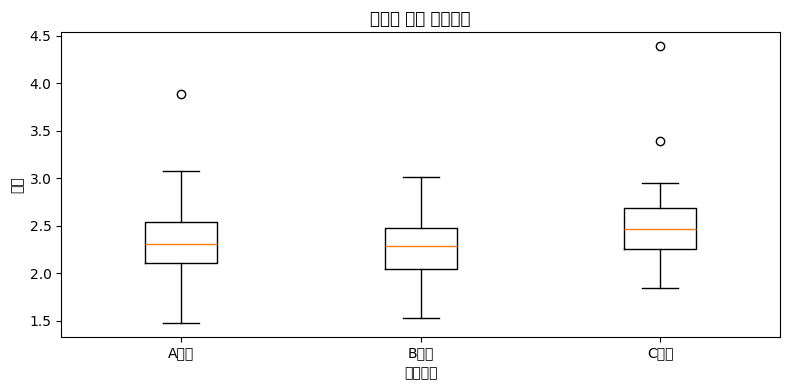

,median,mean,std,count
설비라인,,,,
A라인,2.313,2.328,0.371,71
B라인,2.287,2.269,0.309,68
C라인,2.469,2.516,0.443,41


In [ ]:
names = ["A라인","B라인","C라인"]
groups = [demo_df.loc[demo_df["설비라인"]==x,"진동"] for x in names]

plt.figure(figsize=(8,4))
plt.boxplot(groups, tick_labels=names)
plt.title("라인별 진동 박스플롯")
plt.xlabel("설비라인")
plt.ylabel("진동")
plt.tight_layout()
plt.show()

display(
    demo_df.groupby("설비라인")["진동"]
    .agg(["median","mean","std","count"])
    .round(3)
)

### 🔍 박스플롯에서 볼 것
- 중앙선 → 중앙값
- 상자 길이 → 가운데 50%의 퍼짐
- 수염 밖 점 → 이상치 **후보**

수염 밖 점이 곧 고장을 뜻하지는 않습니다.

## 21-3. `countplot()` vs `barplot()`

```python
sns.countplot(data=demo_df, x="설비라인")        # 몇 개인가?
sns.barplot(data=demo_df, x="설비라인", y="진동") # 평균이 어떻게 다른가?
```

/tmp/ipykernel_957/1084790299.py:10: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/1084790299.py:10: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/1084790299.py:10: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/1084790299.py:10: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/1084790299.py:10: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/1084790299.py:10: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/1084790299.py:10: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layou

/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

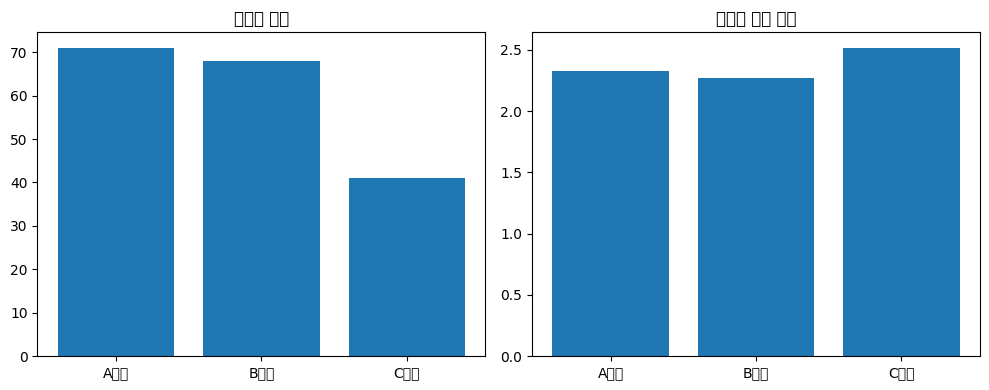

In [ ]:
counts = demo_df["설비라인"].value_counts().reindex(["A라인","B라인","C라인"])
means = demo_df.groupby("설비라인")["진동"].mean().reindex(["A라인","B라인","C라인"])

fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].bar(counts.index, counts.values)
axes[0].set_title("라인별 개수")
axes[1].bar(means.index, means.values)
axes[1].set_ylim(bottom=0)
axes[1].set_title("라인별 평균 진동")
plt.tight_layout()
plt.show()

### 핵심
- `countplot` → **표본 수**
- `barplot` → **숫자형 값의 대표값 비교**

`barplot`의 오차선 의미와 기본값은 **Seaborn 버전 및 `errorbar=` 설정에 따라 달라질 수 있으므로**, 통계적 의미가 중요하면 설정을 확인하세요.

## 21-4. `scatterplot()` — 방향·밀집·그룹

```python
sns.scatterplot(
    data=demo_df,
    x="온도",
    y="진동",
    hue="판정",
    alpha=0.6
)
```

/tmp/ipykernel_957/231836867.py:8: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/231836867.py:8: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/231836867.py:8: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/231836867.py:8: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/231836867.py:8: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/231836867.py:8: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/231836867.py:8: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_

/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/o

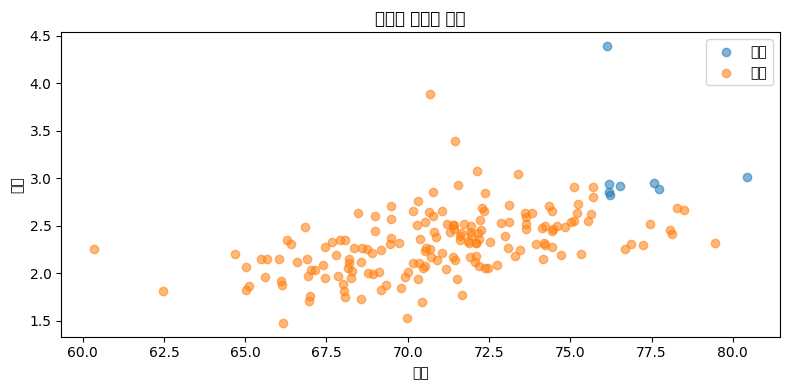

온도-진동 상관계수: 0.527


In [ ]:
plt.figure(figsize=(8,4))
for label, part in demo_df.groupby("판정"):
    plt.scatter(part["온도"], part["진동"], alpha=0.55, label=label)
plt.title("온도와 진동의 관계")
plt.xlabel("온도")
plt.ylabel("진동")
plt.legend()
plt.tight_layout()
plt.show()

print("온도-진동 상관계수:",
      round(demo_df[["온도","진동"]].corr().iloc[0,1],3))

### 🔍 산점도에서 볼 것
- 방향: 우상향/우하향
- 밀집: 한 줄에 가까운가, 넓게 퍼지는가
- 그룹: 특정 판정이 어느 영역에 몰리는가
- 동떨어진 점: 추가 확인 후보

`hue`는 단순 장식이 아니라 **그룹별 패턴 차이를 읽을 때** 유용합니다.

## 21-5. `heatmap()` — 상관관계를 색으로 압축

```python
corr = demo_df[["온도","진동"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
```

/tmp/ipykernel_957/69998087.py:13: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/69998087.py:13: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/69998087.py:13: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/69998087.py:13: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/69998087.py:13: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/69998087.py:13: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_957/69998087.py:13: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyke

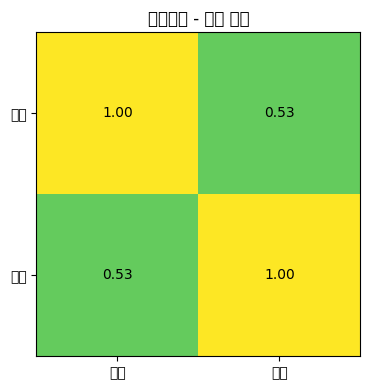

In [ ]:
corr = demo_df[["온도","진동"]].corr()

fig, ax = plt.subplots(figsize=(5,4))
ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns)
ax.set_yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")

ax.set_title("상관행렬 - 해석 연습")
plt.tight_layout()
plt.show()

### 🔍 Heatmap에서 볼 것
1. 대각선 1은 자기 자신 → 제외
2. 큰 양수 → 같은 방향의 선형 관계
3. 큰 음수 → 반대 방향의 선형 관계
4. 0에 가까움 → **선형 관계**가 약함

상관계수 0에 가깝다고 모든 형태의 관계가 없다는 뜻은 아닙니다. 곡선형 관계는 산점도도 확인하세요.

## 21-6. 상황별 Seaborn 선택표

| 질문 | 추천 코드 | 그래프에서 볼 것 |
|---|---|---|
| 숫자 1개 분포 | `histplot()` | 중심·퍼짐·꼬리 |
| 중앙값·이상치 후보 | `boxplot()` | 중앙값·IQR·수염 밖 점 |
| 범주별 개수 | `countplot()` | 데이터 불균형 |
| 범주별 평균/대표값 | `barplot()` | 그룹 차이 |
| 숫자 2개 관계 | `scatterplot()` | 방향·밀집·이상점 |
| 그룹별 관계 | `hue=` | 패턴 차이 |
| 여러 숫자 관계 | `.corr()` + `heatmap()` | 강한 양/음 관계 |
| 점이 겹침 | `alpha=` | 밀집 영역 |

## 21-7. 그래프를 문장으로 바꾸는 공식

```text
무엇이 보였나
→ 어느 그룹/구간에서
→ 어떤 방향/차이인가
→ 단정하지 않고 의미 설명
```

예:
> C라인의 진동 중앙값이 상대적으로 높고 일부 큰 값이 관찰된다. 따라서 C라인을 추가 점검 후보로 볼 수 있다.